In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import numpy as np

In [2]:
raw_data = pd.read_csv("../Data/Learning curves/milk_emissions_World_ts.csv")

raw_data["Year"] = raw_data["Year"].astype(str)

data = raw_data[["Year", "Element", "Value"]]

formatted_data = data.pivot(
    index="Year", columns="Element", values="Value"
).reset_index()
formatted_data.columns.name = None

formatted_data = formatted_data.rename(
    columns={
        "Year": "year",
        "Emissions intensity": "emissions_intensity",
        "Production": "production",
    }
)

formatted_data["cumulative_production"] = formatted_data["production"].cumsum()

formatted_data["log_cumulative_production"] = np.log(
    formatted_data["cumulative_production"]
)
formatted_data["log_emissions_intensity"] = np.log(
    formatted_data["emissions_intensity"]
)

formatted_data

,year,emissions_intensity,production,cumulative_production,log_cumulative_production,log_emissions_intensity
0,1961,1.9875,313612917.9,3.136129e+08,19.563670,0.686878
1,1962,1.9666,316029141.7,6.296421e+08,20.260662,0.676306
2,1963,1.9866,312809648.7,9.424517e+08,20.663995,0.686425
3,1964,1.9384,317601192.4,1.260053e+09,20.954420,0.661863
4,1965,1.8538,332499780.1,1.592553e+09,21.188604,0.617238
...,...,...,...,...,...,...
58,2019,0.9815,720709274.6,2.803328e+10,24.056658,-0.018673
59,2020,0.9623,748966087.5,2.878224e+10,24.083024,-0.038429
60,2021,0.9535,763470404.2,2.954571e+10,24.109204,-0.047616
61,2022,0.9495,769024807.5,3.031474e+10,24.134900,-0.051820


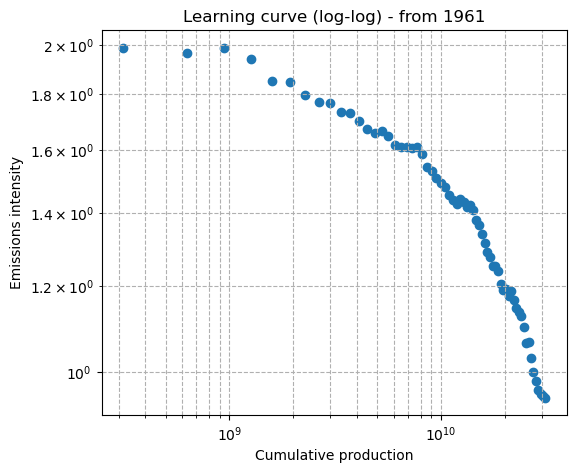

In [ ]:
cutoff_graph = "1961"

graph_data = formatted_data[formatted_data["year"] >= cutoff_graph]

plt.figure(figsize=(6, 5))

plt.scatter(graph_data["cumulative_production"], graph_data["emissions_intensity"])

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Cumulative production")
plt.ylabel("Emissions intensity")
plt.title(f"Learning curve (log-log) - from {cutoff_graph}")

plt.grid(True, which="both", ls="--")

plt.show()

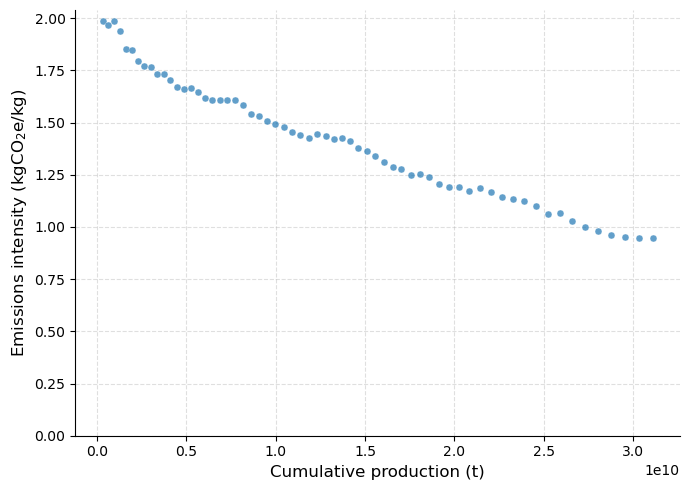

In [9]:
import matplotlib.pyplot as plt

plt.style.use("default")

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    graph_data["cumulative_production"],
    graph_data["emissions_intensity"],
    s=25,
    alpha=0.7,
    edgecolors="white",
    linewidth=0.3,
)

ax.set_xlabel("Cumulative production (t)", fontsize=12)
ax.set_ylabel("Emissions intensity (kgCO$_2$e/kg)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## Milk

### Wright curve

In [36]:
cutoff = "1990"

formatted_data = (
    formatted_data[formatted_data["year"] >= cutoff].sort_values("year").copy()
)

# baseline
S0 = formatted_data["cumulative_production"].iloc[0]
C0 = formatted_data["emissions_intensity"].iloc[0]

# normalized variables
formatted_data["log_ratio_production"] = np.log(
    formatted_data["cumulative_production"] / S0
)

print(S0, C0)

11860578784.800001 1.4282


In [37]:
# regression
X = formatted_data[["log_ratio_production"]]
y = formatted_data["log_emissions_intensity"]

model = LinearRegression()
model.fit(X, y)

alpha = -model.coef_[0]
log_C0 = model.intercept_
C0_fit = np.exp(log_C0)

print("Power constant:", alpha)
print("Learning rate:", 1 - 2**-alpha)

# prediction
formatted_data["emissions_intensity_pred"] = C0_fit * (
    formatted_data["cumulative_production"] / S0
) ** (-alpha)
formatted_data["log_emissions_intensity_pred"] = np.log(
    formatted_data["emissions_intensity_pred"]
)
# R²
r2 = r2_score(
    formatted_data["log_emissions_intensity"],
    formatted_data["log_emissions_intensity_pred"],
)
print("R²:", r2)
print("C0_fit", C0_fit)

Power constant: 0.46610763568202357
Learning rate: 0.2760849252245068
R²: 0.974189222424124
C0_fit 1.509319470975688


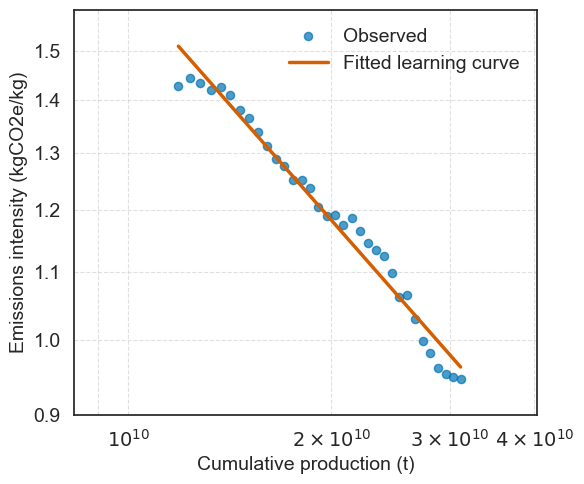

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# STYLE
# =========================================================
STYLE = {
    "font_size_labels": 14,
    "font_size_ticks": 14,
    "legend_size": 14,
    "color_scatter": "#0072B2",
    "color_fit": "#D55E00",
    "scatter_size": 35,
    "scatter_alpha": 0.7,
    "figsize": (6, 5),
}

fig, ax = plt.subplots(figsize=STYLE["figsize"])

x = formatted_data["cumulative_production"]
y = formatted_data["emissions_intensity"]

# =========================================================
# DATA
# =========================================================
ax.scatter(
    x,
    y,
    color=STYLE["color_scatter"],
    s=STYLE["scatter_size"],
    alpha=STYLE["scatter_alpha"],
    label="Observed",
)

sorted_df = formatted_data.sort_values("cumulative_production")

ax.plot(
    sorted_df["cumulative_production"],
    sorted_df["emissions_intensity_pred"],
    color=STYLE["color_fit"],
    linewidth=2.5,
    label="Fitted learning curve",
)

# =========================================================
# LOG SCALE
# =========================================================
ax.set_xscale("log")
ax.set_yscale("log")

# =========================================================
# LIMITS
# =========================================================
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

ax.set_xlim(xmin * 0.7, xmax * 1.3)
ax.set_ylim(ymin, ymax * 1.1)

# =========================================================
# GRID
# =========================================================
ax.grid(True, which="both", linestyle="--", linewidth=0.8, alpha=0.6)

# =========================================================
# 🔥 X TICKS FIX (100% CORRECT PAIRING)
# =========================================================
x_ticks = [1e10, 2e10, 3e10, 4e10]
x_labels = [r"$10^{10}$", r"$2\times10^{10}$", r"$3\times10^{10}$", r"$4\times10^{10}$"]

ax.set_xticks(x_ticks, x_labels)

# =========================================================
# 🔥 Y TICKS FIX (no scientific notation)
# =========================================================
y_ticks = np.arange(np.floor(ymin * 10) / 10, np.ceil(ymax * 10) / 10 + 0.1, 0.1)

y_ticks = np.round(y_ticks, 1)
y_labels = [f"{t:.1f}" for t in y_ticks]

ax.set_yticks(y_ticks, y_labels)

# =========================================================
# TICK STYLE (applies to ALL ticks)
# =========================================================
ax.tick_params(axis="both", which="both", labelsize=STYLE["font_size_ticks"])

# =========================================================
# LABELS
# =========================================================
ax.set_xlabel("Cumulative production (t)", fontsize=STYLE["font_size_labels"])
ax.set_ylabel("Emissions intensity (kgCO2e/kg)", fontsize=STYLE["font_size_labels"])

# =========================================================
# LEGEND
# =========================================================
ax.legend(frameon=False, fontsize=STYLE["legend_size"])

plt.tight_layout()
plt.show()

In [59]:
fig.savefig("../Plots/milk_learning_curve.pdf", bbox_inches="tight")

(0.0, 1.5374354445244724)

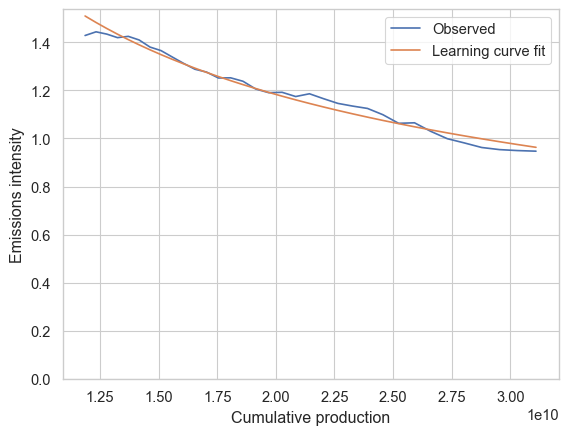

In [8]:
plt.plot(formatted_data["cumulative_production"], formatted_data["emissions_intensity"])

plt.plot(
    formatted_data["cumulative_production"], formatted_data["emissions_intensity_pred"]
)

plt.xlabel("Cumulative production")
plt.ylabel("Emissions intensity")

plt.legend(["Observed", "Learning curve fit"])

plt.gca().set_ylim(bottom=0)

## Potato

In [60]:
raw_data = pd.read_csv("../Data/Learning curves/cereals_emissions_Europe_ts.csv")

raw_data["Year"] = raw_data["Year"].astype(str)

data = raw_data[["Year", "Element", "Value"]]

formatted_data = data.pivot(
    index="Year", columns="Element", values="Value"
).reset_index()
formatted_data.columns.name = None

formatted_data = formatted_data.rename(
    columns={
        "Year": "year",
        "Emissions intensity": "emissions_intensity",
        "Production": "production",
    }
)

formatted_data["cumulative_production"] = formatted_data["production"].cumsum()

formatted_data["log_cumulative_production"] = np.log(
    formatted_data["cumulative_production"]
)
formatted_data["log_emissions_intensity"] = np.log(
    formatted_data["emissions_intensity"]
)

In [61]:
cutoff_graph = "1961"

(0.0, 0.22999499999999998)

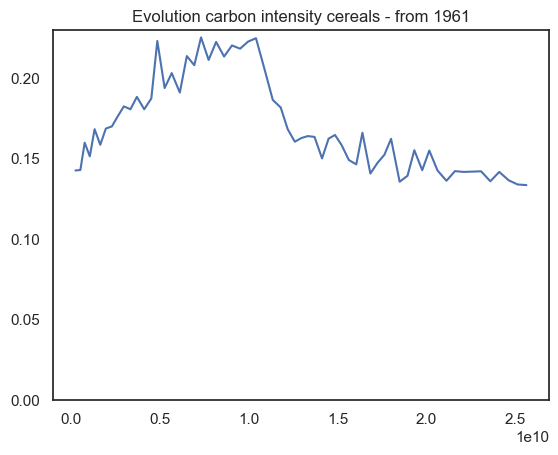

In [62]:
graph_data = formatted_data[formatted_data["year"] >= cutoff_graph].copy()

plt.plot(graph_data["cumulative_production"], graph_data["emissions_intensity"])

plt.title(f"Evolution carbon intensity cereals - from {cutoff_graph}")

plt.gca().set_ylim(bottom=0)

Text(0, 0.5, 'Emissions intensity (kg CO2-eq/kg)')

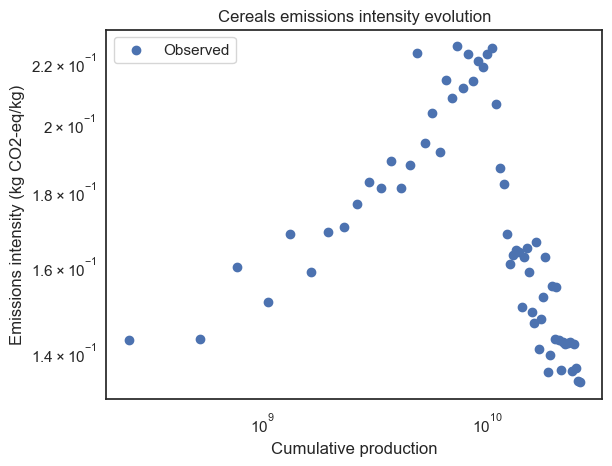

In [63]:
plt.scatter(graph_data["cumulative_production"], graph_data["emissions_intensity"])

plt.xscale("log")
plt.yscale("log")

plt.title("Cereals emissions intensity evolution")

plt.legend(["Observed"])
plt.xlabel("Cumulative production")
plt.ylabel("Emissions intensity (kg CO2-eq/kg)")

In [64]:
cutoff = "1990"

In [66]:
training_data = (
    formatted_data[formatted_data["year"] >= cutoff].sort_values("year").copy()
)

# baseline
S0 = training_data["cumulative_production"].iloc[0]
C0 = training_data["emissions_intensity"].iloc[0]

# normalized variables
training_data["log_ratio_production"] = np.log(
    training_data["cumulative_production"] / S0
)

# regression
X = training_data[["log_ratio_production"]]
y = training_data["log_emissions_intensity"]

model = LinearRegression()
model.fit(X, y)

alpha = -model.coef_[0]
log_C0 = model.intercept_
C0_fit = np.exp(log_C0)

print("Power constant:", alpha)
print("LR:", 1 - 2**-alpha)

# prediction
training_data["emissions_intensity_pred"] = C0_fit * (
    training_data["cumulative_production"] / S0
) ** (-alpha)
training_data["log_emissions_intensity_pred"] = np.log(
    training_data["emissions_intensity_pred"]
)
# R²
r2 = r2_score(
    training_data["log_emissions_intensity"],
    training_data["log_emissions_intensity_pred"],
)
print("R²:", r2)
print("C0_fit:", C0_fit)

Power constant: 0.3140720316837243
LR: 0.19563179100585582
R²: 0.731257608217056
C0_fit: 0.1729601711269418


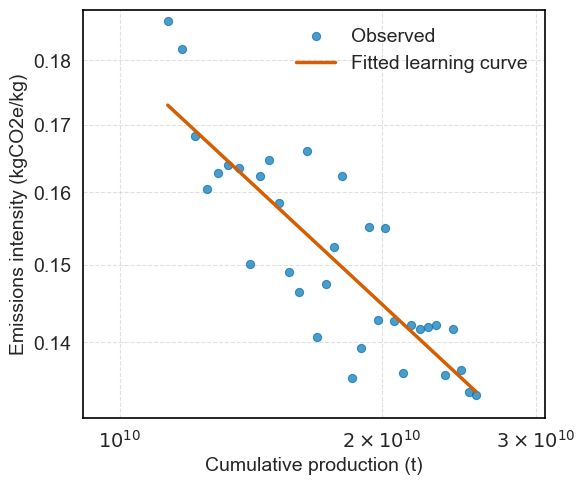

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# STYLE
# =========================================================
STYLE = {
    "font_size_labels": 14,
    "font_size_ticks": 14,
    "legend_size": 14,
    "color_scatter": "#0072B2",
    "color_fit": "#D55E00",
    "scatter_size": 35,
    "scatter_alpha": 0.7,
    "figsize": (6, 5),
}

fig, ax = plt.subplots(figsize=STYLE["figsize"])

x = training_data["cumulative_production"]
y = training_data["emissions_intensity"]

# =========================================================
# DATA
# =========================================================
ax.scatter(
    x,
    y,
    color=STYLE["color_scatter"],
    s=STYLE["scatter_size"],
    alpha=STYLE["scatter_alpha"],
    label="Observed",
)

sorted_df = training_data.sort_values("cumulative_production")

ax.plot(
    sorted_df["cumulative_production"],
    sorted_df["emissions_intensity_pred"],
    color=STYLE["color_fit"],
    linewidth=2.5,
    label="Fitted learning curve",
)

# =========================================================
# LOG SCALE
# =========================================================
ax.set_xscale("log")
ax.set_yscale("log")

# =========================================================
# LIMITS
# =========================================================
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

ax.set_xlim(xmin * 0.8, xmax * 1.2)
ax.set_ylim(ymin * 0.98, ymax * 1.01)
# =========================================================
# GRID
# =========================================================
ax.grid(True, which="both", linestyle="--", linewidth=0.8, alpha=0.6)

# =========================================================
# 🔥 X TICKS FIX
# =========================================================
x_ticks = [1e10, 2e10, 3e10]
x_labels = [r"$10^{10}$", r"$2\times10^{10}$", r"$3\times10^{10}$"]

ax.set_xticks(x_ticks, x_labels)

# =========================================================
# 🔥 Y TICKS FIX (0.14 → 0.18)
# =========================================================
y_ticks = np.arange(0.14, 0.181, 0.01)
y_labels = [f"{t:.2f}" for t in y_ticks]

ax.set_yticks(y_ticks, y_labels)

# =========================================================
# TICK STYLE
# =========================================================
ax.tick_params(axis="both", which="both", labelsize=STYLE["font_size_ticks"])

# =========================================================
# LABELS
# =========================================================
ax.set_xlabel("Cumulative production (t)", fontsize=STYLE["font_size_labels"])
ax.set_ylabel("Emissions intensity (kgCO2e/kg)", fontsize=STYLE["font_size_labels"])

# =========================================================
# LEGEND
# =========================================================
ax.legend(frameon=False, fontsize=STYLE["legend_size"])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

plt.tight_layout()
plt.show()

In [80]:
fig.savefig("../Plots/potato_learning_curve.pdf", bbox_inches="tight")

(0.0, 0.18914999999999998)

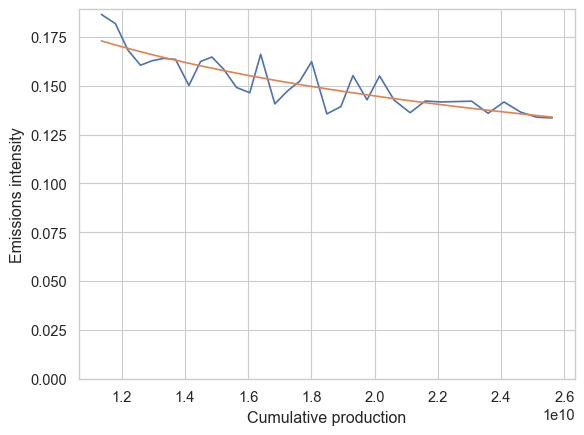

In [88]:
plt.plot(training_data["cumulative_production"], training_data["emissions_intensity"])

plt.plot(
    training_data["cumulative_production"], training_data["emissions_intensity_pred"]
)

plt.xlabel("Cumulative production")
plt.ylabel("Emissions intensity")

plt.gca().set_ylim(bottom=0)